# PA3 - Neural Networks

### `Name: Muhammad Mujtaba`

### `Roll Number: 28100480`

## Overview
In this assignment you will build and evaluate compact neural networks using the MNIST dataset (28×28 handwritten digits). The assignment covers data preprocessing, a from-scratch NumPy implementation and a PyTorch reimplementation, training and basic hyperparameter tuning, and evaluation using metrics and visualisations (accuracy, confusion matrix and example errors); make sure to read all the instructions below carefully.

<table style="width:100%; table-layout:fixed;">
<tr>
  <td style="vertical-align:top; padding:10px; width:33%;">
<h3 style="margin:0 0 6px 0; font-weight:800;">Plagiarism Policy</h3>
    <ul style="margin:6px 0 0 18px; padding:0;">
      <li><span style="color:#e53935; font-weight:700;">All work must be done independently.</span><br>
      Any plagiarism or cheating of work from others, or the internet, will be immediately referred to the DC. If you are confused about what constitutes plagiarism, consult the TAs in a timely manner.</li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">Do not look at anyone else's code.</span></li>
    </ul>
  </td>

  <td style="vertical-align:top; padding:10px; width:33%;">
<h3 style="margin:0 0 6px 0; font-weight:800;">Submission Instructions</h3>
    <ul style="margin:6px 0 0 18px; padding:0;">
      <li>You must submit <strong>all</strong> the notebook <code>.ipynb</code> files and Python <code>.py</code> files on LMS (search how to extract scripts if confused).</li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">Any submissions on Dropbox or email will not be entertained.</span></li>
      <li style="margin-top:6px;">Zip your files, naming it <code>Rollnumber_PAx.zip</code>. Fill in your roll number for each file.</li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">Deviating from the naming convention will incur a penalty.</span></li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">The file structure would look like this:</span></li>
    </ul>
    <pre style="margin:8px 0 0 0; font-size:90%;">26100076_PA3.zip
├─ 26100076_PA3.ipynb
└─ 26100076_PA3.py</pre>
  </td>

  <td style="vertical-align:top; padding:10px; width:33%;">
<h3 style="margin:0 0 6px 0; font-weight:800;">General Instructions</h3>
    <ul style="margin:6px 0 0 18px; padding:0;">
      <li><span style="color:#e53935; font-weight:700;">Make sure to run all cells for credit.</span></li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">Do not remove any pre-written code.</span></li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">You must attempt all parts.</span></li>
      <li style="margin-top:6px;"><span style="color:#e53935; font-weight:700;">Note that all evaluation metrics (accuracy, F1, recall) should be >=95% to get full credit in the evaluation sections.</span></li>
    </ul>
  </td>
</tr>
</table>


## Importing Libraries

All the relevant libraries have been import below. You cannot make any new imports. Do NOT modify the cell below.

In [88]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, roc_curve, auc, classification_report
)
import random
import seaborn as sns
from PIL import Image

np.random.seed(42)

In [89]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu") # For MAC users (comment this out if you are running this locally)

## 1) Download the MNIST Dataset [2 Marks]

- Download the dataset using `torchvision`
- Apply any necessary transforms
- Print the size of the train and test split

In [90]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transforms.ToTensor(),
    download=True
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transforms.ToTensor(),
    download=True
)


## 2) Create Train, Test, Val Splits [6 Marks]

- Split the dataset using the `random_split` function
- You should have the following split:
    - Train: 50,000 samples
    - Test: 10,000 samples
    - Validation: 10,000 samples
- Load the dataset into `DataLoaders`
- Print the size of each split

In [91]:
data_train, data_val = random_split(train_dataset, [50000, 10000])
data_test = test_dataset

size = 64
train_loader = DataLoader(data_train, batch_size= size, shuffle= True)
val_loader = DataLoader(data_val, batch_size= size, shuffle= False)
test_loader = DataLoader(data_test, batch_size= size, shuffle= False)

print(len(data_train))
print(len(data_val))
print(len(data_test))

50000
10000
10000


## 3) Visualisation [4 Marks]

- Write a function `visualise_samples` that visualises a random sample with its label
- It should take 2 arguments
    - `dataloader`
    - `num_samples`
- Make sure to call the function to generate two samples

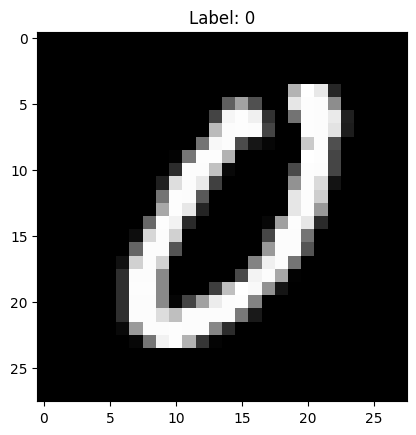

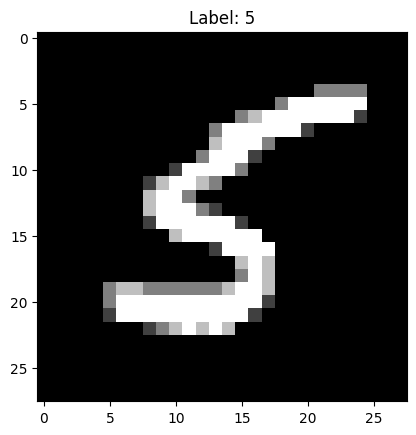

In [92]:
def visualise_samples(dataloader, num_samples = 2):
    data_iter = iter(dataloader) #! opens the dataset
    images, labels = next(data_iter) #!loads the batches in memory
    random_indices = random.sample(range(len(images)), num_samples)
    for idx in random_indices:
        img = images[idx].squeeze()
        label = labels[idx].item()
        plt.imshow(img, cmap = 'gray')
        plt.title(f"Label: {label}")
        plt.show()
        
visualise_samples(train_loader, 2)

## 4) Forward Pass in Numpy [16 Marks]

**4.1) He initialization** [5]

He initialization is used to set the initial weights of neural network layers, especially those with ReLU activations. It helps maintain the variance of activations throughout the network, which improves training stability and convergence.

The formula for He initialization is:
$$
W_{ij} \sim \mathcal{N}\left(0, \frac{2}{\text{in\_dim}}\right)
$$
where $$\text{in\_dim}$$ is the number of input units to the layer. In simple terms, it means the weight matrix is initialised by sampling from a normal distribution with 0 mean and $\frac{2}{\text{in\_dim}}$ variance.

**Write a function, `he_init` function takes two arguments as input:**
- `in_dim`: The number of input units to the layer.
- `out_dim`: The number of output units (neurons) in the layer.

It returns:
- `W`: A weight matrix of shape `(out_dim, in_dim)` initialized using the He initialization method.
- `b`: A bias vector of shape `(out_dim, 1)` initialized to zeros.




In [93]:
def he_init(in_dim, out_dim):
    w = np.random.randn(out_dim, in_dim) * np.sqrt( 2/ in_dim)
    b = np.zeros((out_dim, 1))
    return w,b

**4.2) Weight Initialization** [2]
- Your network should have the following architecture:
    - Input layer: 28x28 (flattened MNIST image)
    - Hidden layer 1: 256 units, ReLU activation
    - Hidden layer 2: 128 units, ReLU activation
    - Output layer: 10 units, softmax activation
- Initialise all the matrices (weights, and biases) using he_init with the correct dimensions.

In [94]:
# Layer 1
input_dim = 28 * 28 
# Layer 2
h1_dim = 256
h2_dim = 128
# Layer 3
output_dim = 10

w1, b1 = he_init(input_dim, h1_dim) #! 256 x 784
w2, b2 = he_init(h1_dim, h2_dim) #! 128 x 256
w3, b3 = he_init(h2_dim, output_dim) #! 10 x 128

**4.3) Activations** [5]
- Write a function for ReLU
- Write a function for Softmax

In [95]:
# Relu
def relu(input):
    return np.maximum(0, input)

In [96]:
# Softmax
def softmax(input):
    shifted_input = input - np.max(input, axis= 0,keepdims= True)
    exp_input = np.exp(shifted_input)
    return exp_input/ np.sum(exp_input, axis= 0, keepdims= True)

**4.4) Forward Pass** [5]
- Now that you have your weights initialized, perform a forward pass on an image from the test set of  MNIST.
- Print the output probabilities and the predicted class

In [97]:
image_test, label_test = test_dataset[0]
input = image_test.numpy().reshape(-1, 1)

z1 = w1 @ input + b1
a1 = relu(z1)

z2 = w2 @ a1 + b2
a2 = relu(z2)

z3 = w3 @ a2 + b3
probability = softmax(z3)
predicted_class =np.argmax(probability)

print("Probability: ", probability)
print("Predicted Class: ", predicted_class)
print("Label: ", label_test)

Probability:  [[0.08324964]
 [0.0773409 ]
 [0.08332835]
 [0.0738834 ]
 [0.11858916]
 [0.11058987]
 [0.1100832 ]
 [0.12999884]
 [0.07426752]
 [0.13866912]]
Predicted Class:  9
Label:  7


# 5) Implement the Backward Pass [20 Marks]
### [6 marks Activations + 14 marks Backward Pass]

In this exercise, you will implement **backpropagation** for a lightweight fully connected neural network using only **NumPy**.   The goal is to compute gradients of weights and biases for each layer using the **chain rule** of calculus.  
Note: caches are not required for this implementation

In [98]:
# ---- Activation derivatives (TO BE IMPLEMENTED) ----
def dsigmoid(a):
    return a * ( 1 -a)

def dtanh(a):
    return (1 - a**2)

def drelu(z):
    return (z > 0).astype(float)

# ---- Backward Pass (TO BE IMPLEMENTED) ----
def backward(W, b, A, Z, Y, activations):
    """
    Compute gradients for a fully-connected MLP (no caches passed around).
    Inputs:
        W, b  : lists of weights/biases, indexed 1..L
        A, Z  : lists of activations and pre-activations, A[0]=X^T, up to A[L]
        Y     : (m,1) labels
        activations: list of names per layer, e.g. [None, 'tanh', 'sigmoid']
    Returns:
        dW, db: lists of gradients, indexed 1..L
    """
    l = len(W) -1
    m = Y.shape[0]
    
    Y = Y.reshape(1, m)
    dA = A[l] - Y
     
    dW = [None] * (l + 1)
    db = [None] * (l + 1)
    
    for x in range(l, 0, -1):
        if activations[x] == "relu":
            dZ = dA * drelu(Z[x])
        if activations[x] == "tanh":
            dZ = dA * dtanh(A[x])
        if activations[x] == "sigmoid":
            dZ = dA * dsigmoid(A[x])
        
        dW[x] = (dZ @ A[x -1].T) / m
        db[x] = np.mean(dZ, axis= 1, keepdims= True)
        
        dA =W[x].T @ dZ
            
    return dW, db


**Backprop Testing (Just run the code block below without changing anything)**

In [99]:
np.random.seed(0)
m = 4
X = np.random.randn(m,2)
Y = (np.random.rand(m,1) > 0.5).astype(int)

W = [None, np.random.randn(3,2)*0.1, np.random.randn(1,3)*0.1]
b = [None, np.zeros((3,1)), np.zeros((1,1))]
Z = [None,
     np.random.randn(3,m),
     np.random.randn(1,m)]
A = [X.T,
     np.tanh(Z[1]),
     1/(1+np.exp(-Z[2]))]

activations = [None, "tanh", "sigmoid"]

dW, db = backward(W, b, A, Z, Y, activations)

print("dW[1] shape:", None if dW[1] is None else dW[1].shape)
print("db[1] shape:", None if db[1] is None else db[1].shape)
print("dW[2] shape:", None if dW[2] is None else dW[2].shape)
print("db[2] shape:", None if db[2] is None else db[2].shape)

dW[1] shape: (3, 2)
db[1] shape: (3, 1)
dW[2] shape: (1, 3)
db[2] shape: (1, 1)


## 6) Neural Networks In PyTorch [52 Marks]

**6.1) Helper Function** [2]

- Create a function `count_parameters` that takes in a model and returns its parameter count.

In [100]:
def count_parameters(model):
    total = 0;
    for p in model.parameters():
        if p.requires_grad:
            total += p.numel();
    return total

**6.2) Fully-Connected Neural Network (FCNN) for Digit Classification in PyTorch** [5]
- Create a FCNN utilising ReLU activations with more than 200,000 parameters. Print its parameter count.
- Note: You are NOT allowed to use convolutions.

In [101]:
class FCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Flatten(), 
            nn.Linear(784, 512), nn.ReLU(), 
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)
    
model = FCNN().to(DEVICE)
print("No. of Parameters: ", count_parameters(model))

No. of Parameters:  567434


**6.3) Hyperparameters** [5]
- Define the criterion, optimizer, and learning rate
- Do NOT change the number of epochs
- In a markdown cell, explain the choice of your criterion (loss function)

In [102]:
EPOCHS = 10
LR = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr= LR)

Ans: I used it because it is the standard loss function for multi-class classification problems as it combines logSoftMax + Negative log-livelihood in a single Function. Also it directly measures how well the predicted probability matches the true color label, making it ideal for training neural networks

**6.4) Training and Evaluation Functions** [15]
- Write a function `train` that takes in the model, dataloader, optimizer, and criterion, and trains the model for one epoch. It should return the average loss and accuracy for that epoch.
- Write a function `evaluate` that takes in the model, dataloader, and criterion, and evaluates the model on the validation or test set. It should return the average loss and accuracy.
- In a markdown cell below, also explain the use of the following functions:
    -  `optimizer.zero_grad()`
    -  `loss.backward()`
    -  `optimizer.step()`

In [103]:
# train function 
def train(model, dataloader, optimizer, criterion):
    model.train()
    runningloss = 0.0
    correct = 0
    total = 0
    
    for image, label in dataloader:
        image, label = image.to(DEVICE), label.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(image)
        loss = criterion(outputs, label)
        loss.backward()
        optimizer.step()
        
        runningloss += loss.item() * image.size(0)
        
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == label).sum().item()
        total += label.size(0)
        
    average_loss = runningloss / total
    accuracy = correct / total

    return average_loss, accuracy
        

In [104]:
# evaluate function below

def evaluate(model, dataloader, criterion):
    model.eval()
    runningloss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for image, label in dataloader:
            image, label = image.to(DEVICE), label.to(DEVICE)
            outputs = model(image)
            loss = criterion(outputs, label)
            
            runningloss += loss.item() * image.size(0)
            
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == label).sum().item()
            total += label.size(0)
            
    average_loss = runningloss / total
    accuracy = correct / total
    
    return average_loss, accuracy 

Ans: 
1. optimizer.zero_grad()
    Optimizer.zero_grad() clears old gradients so the update uses only the current batch. Because in Pytorch, gradients add up by default. We must clear the gradients from the previous step before computing gradients for the current batch, otherwise it would corrupt the optimization step by poining gradients in the wrong direction.

2. loss.backward()
    This function initiated Backpropagation. It computes the gradient of the loss function with respect to the every model parameter that has requires_grad = True. It stores these gradients in the .grad attribute of each

3. optimizer.step()
    Uses the gradients computed by loss.backward() to update the model parameters.
    The exact update rule depends on the optimizer:
     - Adam: adaptive learning rate update
     - SGD: gradient descent step

**6.5) Training Loop** [10]
- Write a loop to train your model for the specified number of epochs.
- For each epoch, print the training loss, training accuracy, validation loss, and validation accuracy.
- Use your `train` and `evaluate` functions to get these values for each epoch.
- Save the model with the best validation accuracy.
- Plot the loss and accuracy curves (for both train and val set).
- Make sure to label the graphs correctly.

Ephoch:  0 / 10
Train Loss:  0.28370818772554396  | Train Accuracy:  0.9155
Val loss:  0.12946856119632721  | Val Accuracy:  0.9602
Ephoch:  1 / 10
Train Loss:  0.10536204179883003  | Train Accuracy:  0.96728
Val loss:  0.0965653203368187  | Val Accuracy:  0.9703
Ephoch:  2 / 10
Train Loss:  0.07095032339215279  | Train Accuracy:  0.97808
Val loss:  0.08275039763152599  | Val Accuracy:  0.9749
Ephoch:  3 / 10
Train Loss:  0.05094462369993329  | Train Accuracy:  0.98322
Val loss:  0.06927433699928225  | Val Accuracy:  0.9802
Ephoch:  4 / 10
Train Loss:  0.04006766131579876  | Train Accuracy:  0.98728
Val loss:  0.07479984040707349  | Val Accuracy:  0.9781
Ephoch:  5 / 10
Train Loss:  0.03232207355419174  | Train Accuracy:  0.98954
Val loss:  0.0765911921158433  | Val Accuracy:  0.978
Ephoch:  6 / 10
Train Loss:  0.028357858522571625  | Train Accuracy:  0.99144
Val loss:  0.07700995995737613  | Val Accuracy:  0.979
Ephoch:  7 / 10
Train Loss:  0.023068781082304195  | Train Accuracy:  0.9

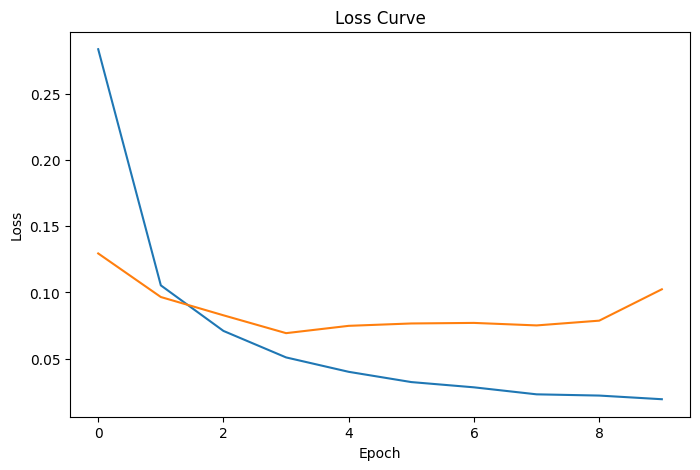

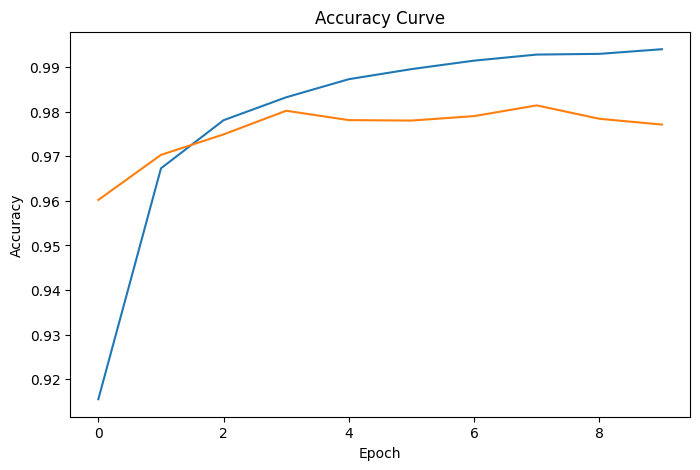

In [105]:
trainlosses = []
vallosses = []
trainaccuracies = []
valaccuracies = []

best_val_accuracy = 0.0
best_model_path = "best_model"

for epoch in range(EPOCHS):
    trainloss, trainaccuracy = train(model, train_loader, optimizer, criterion)
    valloss, valaccuracy = evaluate(model, val_loader, criterion)
    
    trainlosses.append(trainloss)
    vallosses.append(valloss)
    trainaccuracies.append(trainaccuracy)
    valaccuracies.append(valaccuracy)
    
    print("Ephoch: ", epoch, "/ 10")
    print("Train Loss: ", trainloss, " | Train Accuracy: ", trainaccuracy)
    print("Val loss: ", valloss, " | Val Accuracy: ", valaccuracy)
    
    if valaccuracy > best_val_accuracy:
        best_val_accuracy = valaccuracy
        torch.save(model.state_dict(), best_model_path)

print("Best Accuracy: ", best_val_accuracy)

plt.figure(figsize=(8,5))
plt.plot(trainlosses, label = 'Train Loss')
plt.plot(vallosses, label = 'Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(trainaccuracies, label = 'Train Accuracy')
plt.plot(valaccuracies, label = 'Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

**6.6) Evaluation** [10]
- Load the model with the best validation accuracy.
- Evaluate this model on the test set and report the following:
    - Accuracy **(should be higher than 95%)**
    - F1 (macro) **(should be higher than 95%)**
    - Recall (macro) **(should be higher than 95%)**
- Print the classification report.
- Visualise the confusion matrix.
- Plot the ROC curve.
- Write a function `visualise_incorrect` that visualises the incorrectly labelled samples with their true and predicted labels.

In [109]:
model.load_state_dict(torch.load("best_model"))
model.eval()

labels = []
preds = []
probs = []

with torch.no_grad():
    for image, label in test_loader:
        output = model(image)
        prob = torch.softmax(output, dim = 1)
        _, predict = torch.max(output, 1)
        
        labels.extend(label.numpy())
        preds.extend(predict.numpy())
        probs.extend(prob.numpy())

In [110]:
# Show required evaluation metrics below
        
labels = np.array(labels)
preds = np.array(preds)
probs = np.array(probs)

accuracy = accuracy_score(labels, preds)
f1 = f1_score(labels, preds, average = 'macro')
recall = recall_score(labels, preds, average= 'macro')

print("Accuracy: ", accuracy)
print("F1 score: ", f1)
print("Recall: ", recall)

print("classification_report: ")
print(classification_report(labels, preds))

Accuracy:  0.9798
F1 score:  0.9797188978749203
Recall:  0.979774000814345
classification_report: 
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.99      0.98      0.98      1010
           4       0.97      0.98      0.98       982
           5       0.98      0.99      0.98       892
           6       0.98      0.98      0.98       958
           7       0.99      0.96      0.97      1028
           8       0.97      0.98      0.98       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



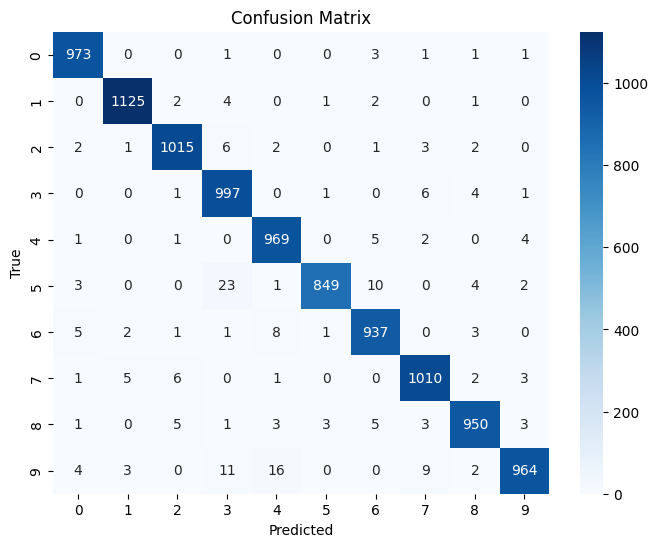

In [ ]:
# Plot confusion matrix below
cm = confusion_matrix(label, preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot= True,fmt = "d", cmap= "Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Plot ROC curve below

Visualising Incorrect Samples


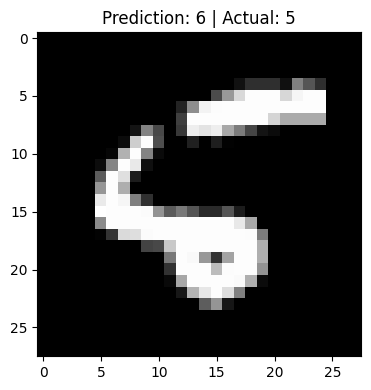

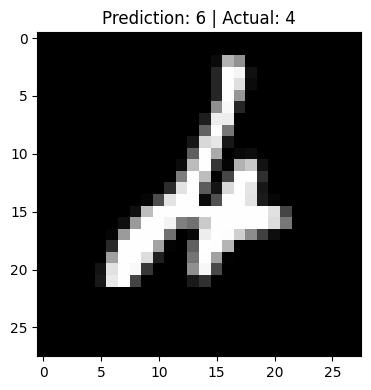

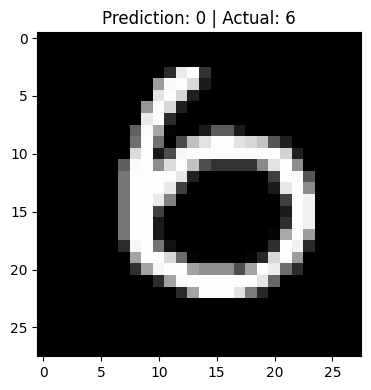

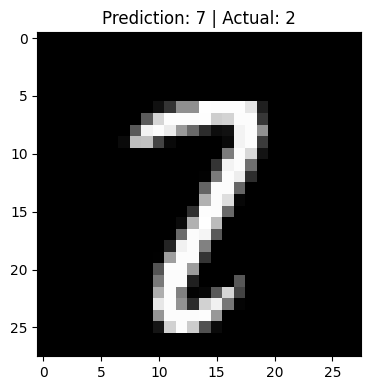

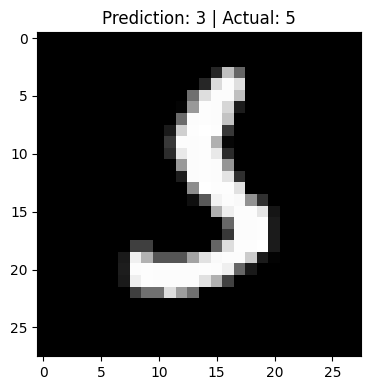

In [ ]:
# Write visualise function below and make sure to visalize some atleast two samples
def visualise_incorrect(model, dataloader, device, num_samples = 5):
    model.eval()
    mistakes = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            _, preds = torch.max(output, 1)
            
            incorrect_mask = preds != labels
            
            if incorrect_mask.sum() > 0:
                bad_images = images[incorrect_mask]
                bad_preds = preds[incorrect_mask]
                true_label = labels[incorrect_mask]
                
                for i in range(len(bad_images)):
                    mistakes.append((bad_images[i].cpu(), bad_preds[i].item(), true_label[i].item()))
                    if len(mistakes) >= num_samples:
                        break
            if len(mistakes) >= num_samples:
                break
            
    
    for i, (img, pred, true) in enumerate(mistakes):
        plt.figure(figsize=(4,4))
        plt.imshow(img.squeeze(), cmap= 'gray')
        plt.title("Prediction: {} | Actual: {}".format(pred, true))
        plt.tight_layout()
        plt.show()
        
print("Visualising Incorrect Samples")
visualise_incorrect(model, test_loader, DEVICE, num_samples= 5)

**6.7) Out-of-distribution (OOD) Evaluation** [5]
- Write any digit on a piece of paper and take a photo of it.
- Load the photo and apply any processing necessary to get the image ready to be passed into the FCNN.
- Visualise the image.
- Run inference on the image and print all the output probabilities and its predicted class.
- Comment on whether the model is able to correctly predict the digit? Why or why not? 

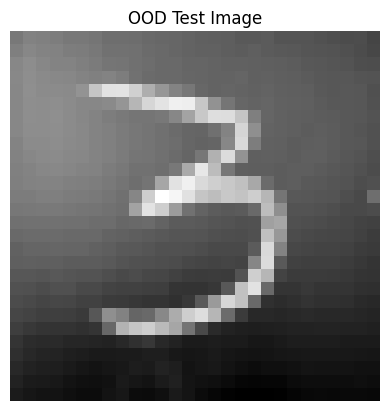

Predicted Class 3


In [ ]:
image_path = r"C:\Users\HP\OneDrive\Desktop\LUMS_3rd_Semester\CS 331 AI ML\Assignments\PA3_Student\Image3.jpg"
image = Image.open(image_path).convert('L')

transform = transforms.Compose([transforms.Resize((28,28)), transforms.ToTensor(), transforms.Normalize((0.5,),(0.5,))])


image_tensor = transform(image).unsqueeze(0)

plt.imshow(image_tensor.squeeze(), cmap ='gray')
plt.title("OOD Test Image")
plt.axis('off')
plt.show()

model.eval()
with torch.no_grad():
    output = model(image_tensor)
    probabilities = torch.softmax(output, dim =1).numpy().squeeze()
    predicted_class = np.argmax(probabilities)

print("Predicted Class", predicted_class)